# 基于pandas的福州大学教务处教学通知的数据分析报告

In [ ]:
!pip install lxml

In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [ ]:
import requests
import re
import csv
import os
from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

## Part 1：准备工作与预处理

In [22]:
fzu_data = pd.read_csv("information.csv",na_values=['无附件','-1','-1'])
fzu_data = fzu_data.groupby("标题").agg({
    "日期": "first",
    "发布月份": "first",
    "发布单位": "first",
    "链接": "first",
    "附件名": lambda x: "|".join(x.dropna().astype(str).unique()),
    "文件id": lambda x: "|".join(x.dropna().astype(str).unique()),
    "下载次数": "sum"
}).reset_index()

## Part 2：通知发布单位，以及他们发布的通知数量比例

In [23]:
def t2():
    # 发布单位都有谁，并且统计每个发布单位的通知数量占总数的比例
    data_documents=fzu_data["发布单位"].unique()
    data_documents_count=fzu_data["发布单位"].value_counts().sort_index()
    sum_count=data_documents_count.sum()
    data_documents_count=data_documents_count/sum_count
    plt.figure(figsize=(10,6))
    plt.bar(data_documents_count.index, data_documents_count.values)
    for i, v in enumerate(data_documents_count.values):
        plt.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom')
    plt.xlabel("发布单位")
    plt.ylabel("通知数量比例")
    plt.title("各发布单位通知数量占比")

## Part 3：附件下载次数与通知人的关系

In [24]:
def t3():
    # 附件下载次数与通知单位的关系
    data_documents=fzu_data["发布单位"].unique()
    data_documents_count=fzu_data.groupby("发布单位").下载次数.sum()
    plt.figure(figsize=(10,6))
    plt.bar(data_documents_count.index, data_documents_count.values)
    for i, v in enumerate(data_documents_count.values):
        plt.text(i, v + 0.01, f"{v}", ha='center', va='bottom')
    plt.xlabel("发布单位")
    plt.ylabel("总下载次数")
    plt.title("各发布单位通知总下载次数")

## Part 4：通知发布的高峰期

In [25]:
def t4():
    # 统计每天发布的通知数量
    data_date=fzu_data["日期"].unique()
    data_date_count=fzu_data["日期"].value_counts()
    # 按照月份统计发布的通知数量，不区分年份
    data_month_count=fzu_data["发布月份"].value_counts()
    plt.figure(figsize=(10,6))
    plt.bar(data_month_count.index, data_month_count.values)
    plt.xlabel("发布月份")
    plt.ylabel("通知数量")
    plt.title("各月份通知发布数量")

## Part 5：附件数量与下载次数的关系

In [26]:
def t5():
    # 统计每个通知的附件数量，并分析附件数量与下载次数的关系
    fzu_data["附件数量"] = fzu_data["附件名"].apply(lambda x: len(str(x).split("|")) if pd.notna(x) else 0)
    plt.figure(figsize=(10,6))
    plt.bar(fzu_data["附件数量"], fzu_data["下载次数"])
    plt.xlabel("附件数量")
    plt.ylabel("下载次数")
    plt.title("附件数量与下载次数的关系")

## 图表展示

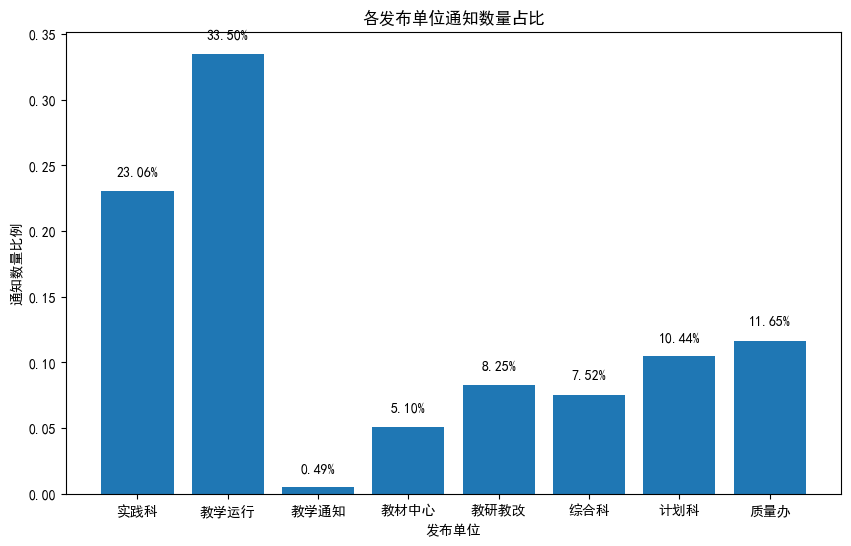

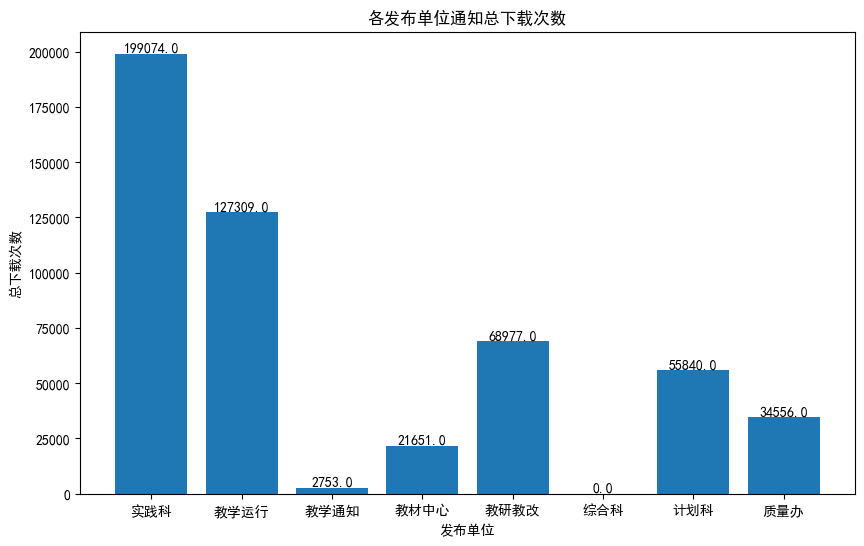

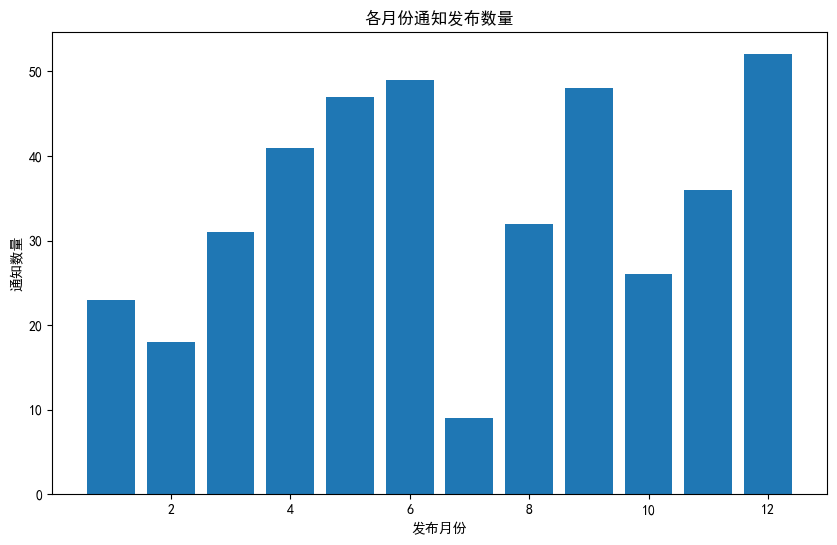

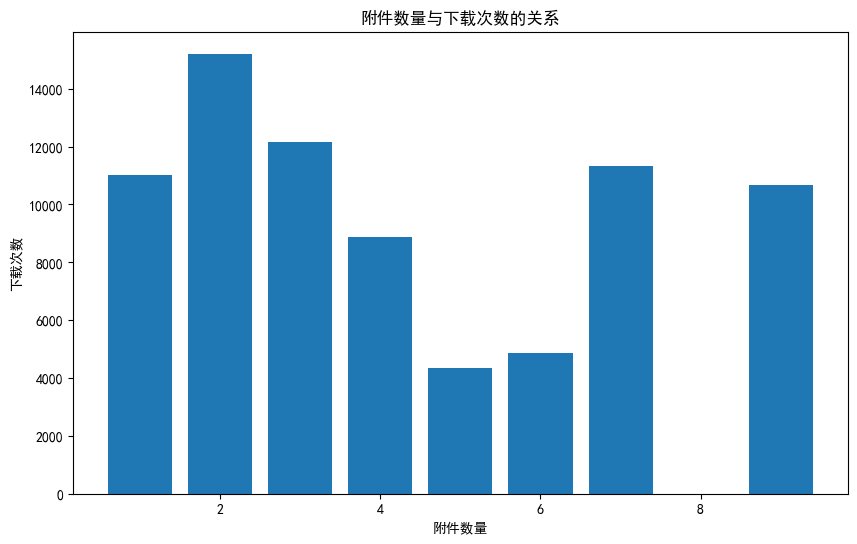

In [27]:
if __name__ == "__main__":
    t2()
    t3()
    t4()
    t5()
    plt.show()